In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import joblib

sns.set(style="whitegrid")
RANDOM_STATE = 42


In [2]:
df = pd.read_csv("shopkart_sales_dataset.csv")

print("First rows:")
display(df.head())

print("Last rows:")
display(df.tail())

print("Shape:", df.shape)


First rows:


,Order_ID,Order_Date,Customer_Age,Gender,City,Category,Qty,Unit Price,Discount,Shipping,Delivery,Sales,Profit,Rating,Profit_Category
0,SK100001,08-07-24,0.0,Male,Bengaluru,Beauty,5,37494,25,427.0,4,140602.50,11270.73,4.0,1
1,SK100002,21-03-25,150.0,Female,Lucknow,Beauty,4,45197,5,288.0,5,171748.60,13467.54,2.0,1
2,SK100003,29-09-24,26.0,Female,Jaipur,Grocery,-2,18665,20,298.0,3,44796.00,2194.68,4.0,0
3,SK100004,10-02-25,53.0,Male,Pune,Grocery,1,5483,120,175.0,9,5208.85,566.00,2.0,0
4,SK100005,10-03-24,33.0,Female,Delhi,Beauty,4,1562,-15,465.0,10,6248.00,880.50,4.0,0


Last rows:


,Order_ID,Order_Date,Customer_Age,Gender,City,Category,Qty,Unit Price,Discount,Shipping,Delivery,Sales,Profit,Rating,Profit_Category
4995,SK104996,15-06-25,40.0,Male,Mumbai,Furniture,4,21147,40,262.0,2,50752.8,3986.73,1.0,1
4996,SK104997,19-04-24,52.0,Female,Pune,Electronics,5,39828,30,166.0,4,139398.0,35836.96,5.0,1
4997,SK104998,13-09-24,56.0,Male,Jaipur,Electronics,1,11116,20,133.0,10,8892.8,437.40,5.0,0
4998,SK104999,18-09-24,21.0,Male,Chennai,Beauty,1,13259,40,205.0,3,7955.4,502.83,2.0,0
4999,SK105000,24-12-24,53.0,Female,Chennai,Furniture,1,28181,30,357.0,5,19726.7,4306.60,2.0,1


Shape: (5000, 15)


In [3]:
df.info()
df.dtypes



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         5000 non-null   object 
 1   Order_Date       5000 non-null   object 
 2   Customer_Age     4950 non-null   float64
 3   Gender           4967 non-null   object 
 4   City             5000 non-null   object 
 5   Category         4973 non-null   object 
 6   Qty              5000 non-null   int64  
 7   Unit Price       5000 non-null   int64  
 8   Discount         5000 non-null   int64  
 9   Shipping         4975 non-null   float64
 10  Delivery         5000 non-null   int64  
 11  Sales            5000 non-null   float64
 12  Profit           5000 non-null   float64
 13  Rating           4978 non-null   float64
 14  Profit_Category  5000 non-null   int64  
dtypes: float64(5), int64(5), object(5)
memory usage: 586.1+ KB


Order_ID            object
Order_Date          object
Customer_Age       float64
Gender              object
City                object
Category            object
Qty                  int64
Unit Price           int64
Discount             int64
Shipping           float64
Delivery             int64
Sales              float64
Profit             float64
Rating             float64
Profit_Category      int64
dtype: object

In [4]:
df.isnull().sum()
df.head()



,Order_ID,Order_Date,Customer_Age,Gender,City,Category,Qty,Unit Price,Discount,Shipping,Delivery,Sales,Profit,Rating,Profit_Category
0,SK100001,08-07-24,0.0,Male,Bengaluru,Beauty,5,37494,25,427.0,4,140602.50,11270.73,4.0,1
1,SK100002,21-03-25,150.0,Female,Lucknow,Beauty,4,45197,5,288.0,5,171748.60,13467.54,2.0,1
2,SK100003,29-09-24,26.0,Female,Jaipur,Grocery,-2,18665,20,298.0,3,44796.00,2194.68,4.0,0
3,SK100004,10-02-25,53.0,Male,Pune,Grocery,1,5483,120,175.0,9,5208.85,566.00,2.0,0
4,SK100005,10-03-24,33.0,Female,Delhi,Beauty,4,1562,-15,465.0,10,6248.00,880.50,4.0,0


In [5]:
df.duplicated().sum()



np.int64(0)

In [6]:
df.describe(include='all')



,Order_ID,Order_Date,Customer_Age,Gender,City,Category,Qty,Unit Price,Discount,Shipping,Delivery,Sales,Profit,Rating,Profit_Category
count,5000,5000,4950.000000,4967,5000,4973,5000.000000,5000.000000,5000.000000,4975.000000,5000.000000,5000.000000,5000.000000,4978.000000,5000.000000
unique,5000,541,NaN,2,8,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,SK105000,29-01-25,NaN,Female,Bengaluru,Sports,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,20,NaN,2495,646,854,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,41.510505,NaN,NaN,NaN,3.006800,25218.403400,18.437000,322.230553,5.505000,62224.273950,10741.262846,3.024106,0.741000
std,NaN,NaN,13.994752,NaN,NaN,NaN,1.417165,14758.076146,12.361739,159.181210,2.878616,50652.012504,10719.868245,1.411590,0.438129
min,NaN,NaN,0.000000,NaN,NaN,NaN,-2.000000,219.000000,-15.000000,50.000000,-3.000000,210.400000,-459.200000,1.000000,0.000000
25%,NaN,NaN,29.000000,NaN,NaN,NaN,2.000000,12897.250000,10.000000,187.000000,3.000000,22136.700000,2874.310000,2.000000,0.000000
50%,NaN,NaN,42.000000,NaN,NaN,NaN,3.000000,25115.500000,20.000000,316.000000,5.000000,47465.400000,7246.335000,3.000000,1.000000
75%,NaN,NaN,53.000000,NaN,NaN,NaN,4.000000,37905.750000,30.000000,461.000000,8.000000,91062.450000,15389.002500,4.000000,1.000000


In [7]:
df['Profit_Category'].value_counts()



Profit_Category
1    3705
0    1295
Name: count, dtype: int64

In [8]:
# Value counts for key categorical columns
for col in ['Gender', 'City', 'Category']:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()



--- Gender ---
Gender
Female    2495
Male      2472
NaN         33
Name: count, dtype: int64

--- City ---
City
Bengaluru    646
Hyderabad    644
Delhi        630
Mumbai       627
Pune         624
Chennai      623
Jaipur       608
Lucknow      598
Name: count, dtype: int64

--- Category ---
Category
Sports         854
Beauty         838
Fashion        833
Electronics    830
Grocery        817
Furniture      801
NaN             27
Name: count, dtype: int64



Profit_Category
1    3705
0    1295
Name: count, dtype: int64


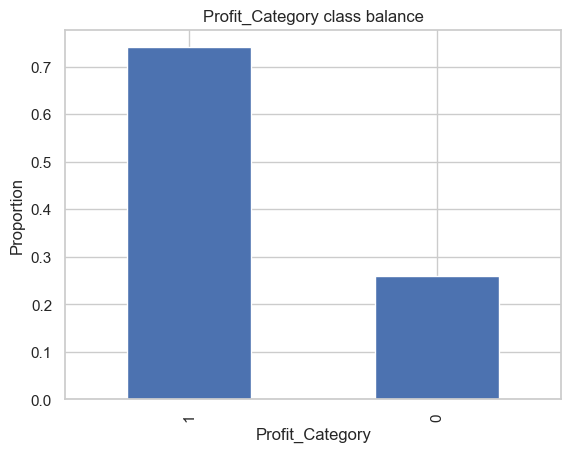

In [9]:
print(df['Profit_Category'].value_counts())
df['Profit_Category'].value_counts(normalize=True).plot(kind='bar', title='Profit_Category class balance')
plt.ylabel('Proportion')
plt.show()

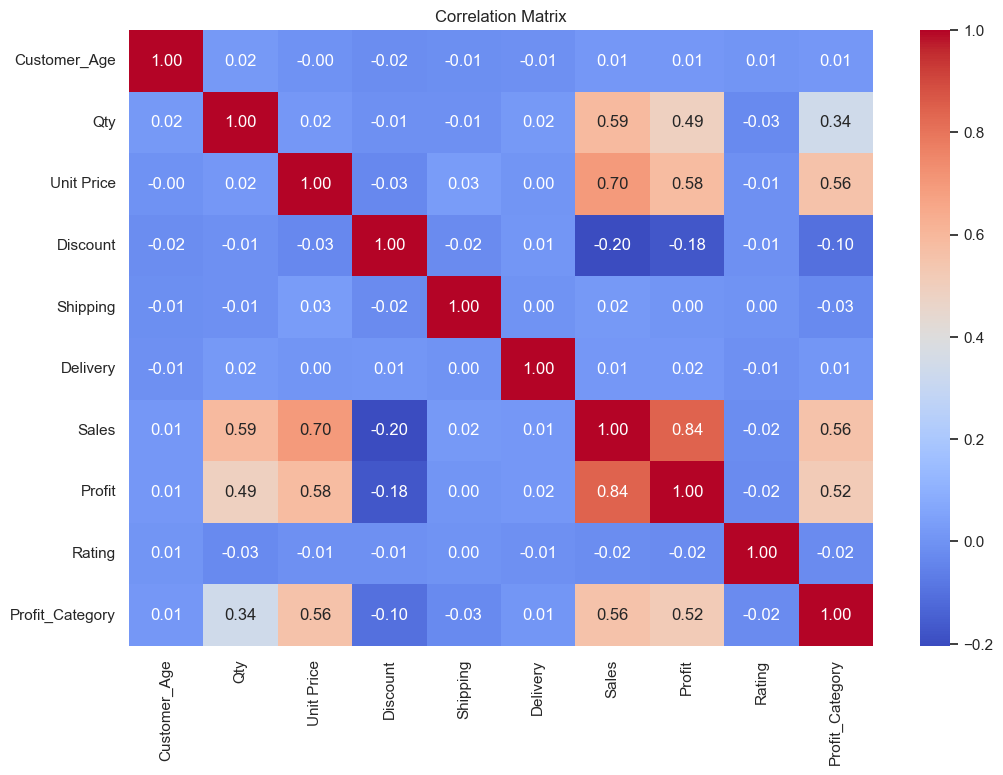

In [10]:
# Correlation matrix (numeric columns only)
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


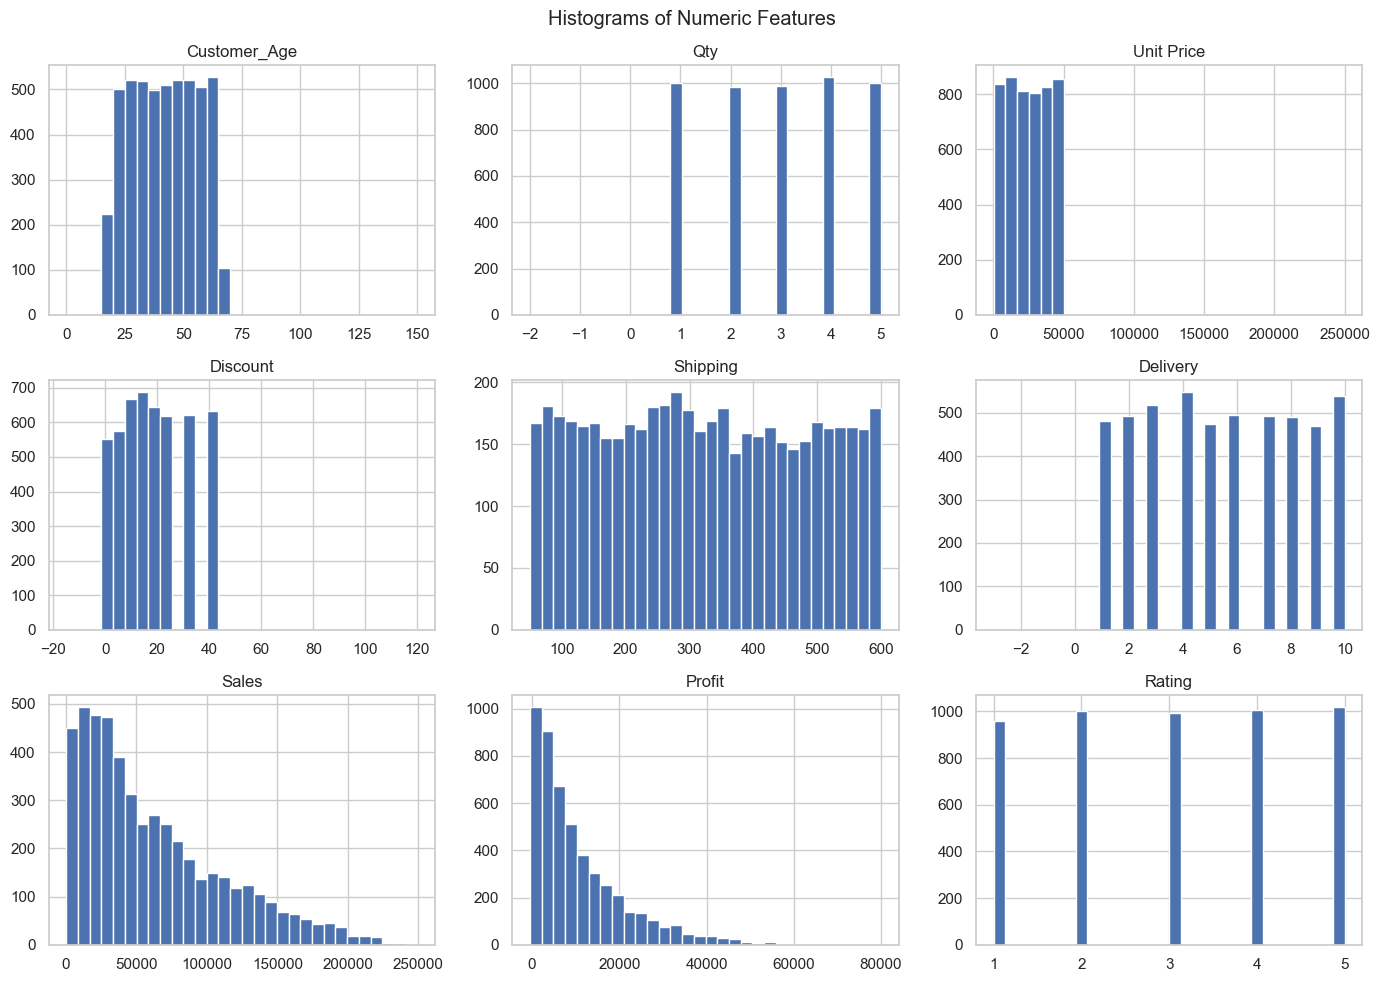

In [11]:
# FIX: histograms were required by the spec but missing from the original notebook
num_cols_for_hist = ['Customer_Age', 'Qty', 'Unit Price', 'Discount', 'Shipping',
                      'Delivery', 'Sales', 'Profit', 'Rating']
df[num_cols_for_hist].hist(figsize=(14, 10), bins=30)
plt.suptitle("Histograms of Numeric Features")
plt.tight_layout()
plt.show()


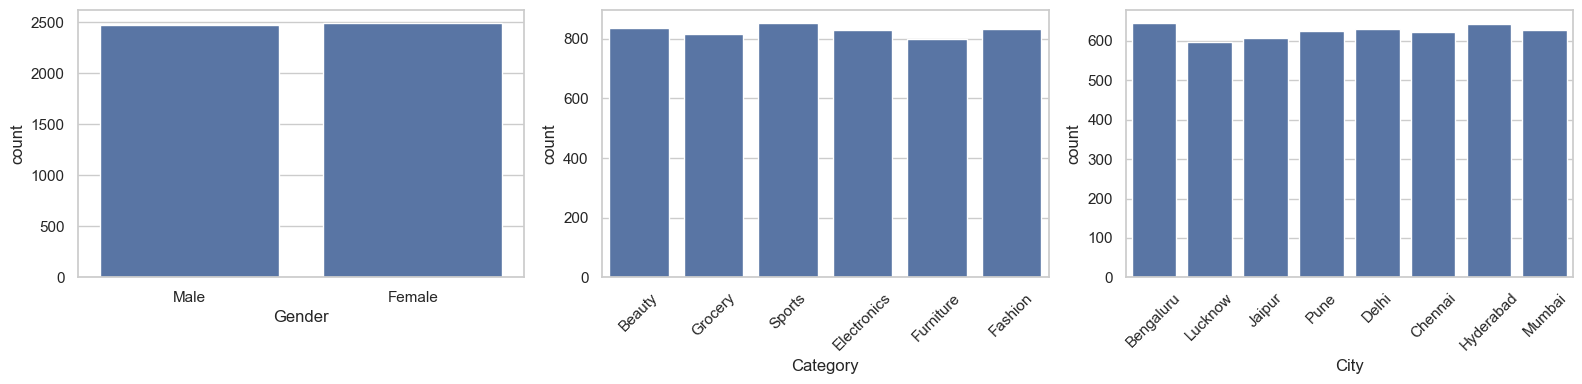

In [12]:
# FIX: count plots were required by the spec but missing from the original notebook
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(x='Gender', data=df, ax=axes[0])
sns.countplot(x='Category', data=df, ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
sns.countplot(x='City', data=df, ax=axes[2])
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


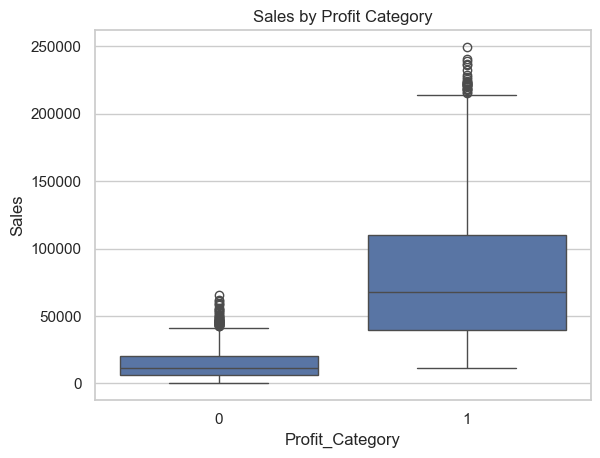

In [13]:
sns.boxplot(x='Profit_Category', y='Sales', data=df)
plt.title("Sales by Profit Category")
plt.show()


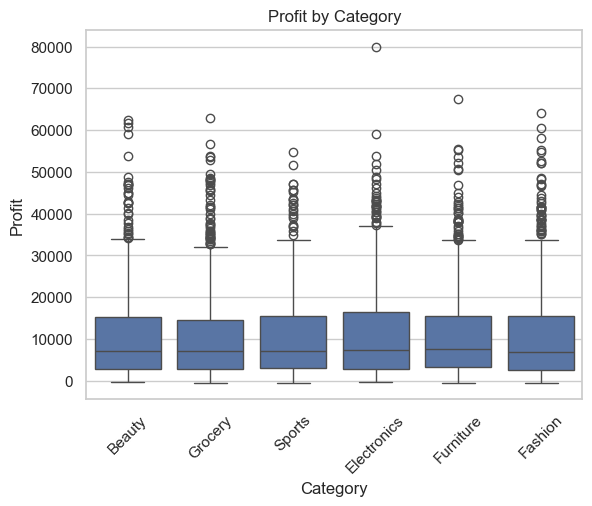

In [14]:
sns.boxplot(x='Category', y='Profit', data=df)
plt.xticks(rotation=45)
plt.title("Profit by Category")
plt.show()


In [ ]:
sns.pairplot(df[['Sales', 'Profit', 'Discount', 'Profit_Category']], hue='Profit_Category')
plt.show()


In [ ]:
# 4.1 Remove duplicates
before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Removed {before - df.shape[0]} duplicate rows")


In [ ]:
# 4.2 FIX: correct invalid values (present in the raw data but never handled in the original notebook)
# Qty should never be negative -> treat as missing, impute later
df.loc[df['Qty'] < 0, 'Qty'] = np.nan

# Discount should never be negative -> treat as missing, impute later
df.loc[df['Discount'] < 0, 'Discount'] = np.nan

# Customer_Age of 0 or absurdly high (>100) is not a realistic customer age -> treat as missing
df.loc[(df['Customer_Age'] <= 0) | (df['Customer_Age'] > 100), 'Customer_Age'] = np.nan

print("Invalid values converted to NaN:")
print(df[['Qty', 'Discount', 'Customer_Age']].isnull().sum())


In [ ]:
# 4.3 Handle missing values
num_cols = df.select_dtypes(include=[np.number]).columns.drop('Profit_Category')
cat_cols = df.select_dtypes(exclude=[np.number]).columns.drop(['Order_ID', 'Order_Date'])

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining missing values:", df.isnull().sum().sum())


In [ ]:
# 4.4 Convert date column
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%y', errors='coerce')
df['Order_Date'].isnull().sum()  # any dates that failed to parse


In [ ]:
# 4.5 Validate categorical values
print("Category values:", df['Category'].unique())
print("Gender values:", df['Gender'].unique())
print("City values:", df['City'].unique())


In [ ]:
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Profit'] < Q1 - 1.5 * IQR) | (df['Profit'] > Q3 + 1.5 * IQR)]
print(f"Profit outliers (IQR method): {len(outliers)} rows")


In [ ]:
sns.boxplot(x='Category', y='Profit', data=df)
plt.xticks(rotation=45)
plt.title("Profit by Category (before outlier removal)")
plt.show()


In [ ]:
def remove_outliers_iqr(data, columns):
    data_clean = data.copy()
    for col in columns:
        Q1 = data_clean[col].quantile(0.25)
        Q3 = data_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        data_clean = data_clean[(data_clean[col] >= lower_bound) & (data_clean[col] <= upper_bound)]
    return data_clean

numeric_cols_for_outliers = ['Sales', 'Profit', 'Discount', 'Customer_Age', 'Rating']
print("Shape before outlier removal:", df.shape)
df = remove_outliers_iqr(df, numeric_cols_for_outliers)  # FIX: cleaned frame is now actually used downstream
df = df.reset_index(drop=True)
print("Shape after outlier removal:", df.shape)


In [ ]:
sns.boxplot(x='Category', y='Profit', data=df)
plt.xticks(rotation=45)
plt.title("Profit by Category (after outlier removal)")
plt.show()


In [ ]:
df['Month'] = df['Order_Date'].dt.month
df['Year'] = df['Order_Date'].dt.year
df['DayOfWeek'] = df['Order_Date'].dt.dayofweek
df['Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

df['ProfitMargin'] = np.where(df['Sales'] > 0, df['Profit'] / df['Sales'], 0)
df['RevenuePerItem'] = np.where(df['Qty'] > 0, df['Sales'] / df['Qty'], 0)

df[['Month', 'Year', 'DayOfWeek', 'Weekend', 'ProfitMargin', 'RevenuePerItem']].head()


In [ ]:
# FIX: the original notebook assigned via `df.loc[:, col] = le.fit_transform(...)`
# on a column that already existed as dtype "object". That silently kept the column
# as object dtype (confirmed by the original notebook's own printed df.dtypes output),
# which later breaks model.fit() with a "could not convert string to float" error.
# Direct column assignment + explicit astype(int) guarantees a numeric dtype.

le_cat = LabelEncoder()
df['Category'] = le_cat.fit_transform(df['Category']).astype(int)

le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender']).astype(int)

# One-Hot Encoding for City
df = pd.get_dummies(df, columns=['City'], drop_first=True)
city_dummy_cols = [c for c in df.columns if c.startswith('City_')]
df[city_dummy_cols] = df[city_dummy_cols].astype(int)

print(df.dtypes)


In [ ]:
X = df.drop(['Profit_Category', 'Order_ID', 'Order_Date'], axis=1)
y = df['Profit_Category']

feature_columns = X.columns.tolist()  # remember exact column order for later use (Step 17)
print("Feature columns:", feature_columns)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(X_train.shape, X_test.shape)


In [ ]:
num_features_to_scale = ['Sales', 'Profit', 'Discount', 'Customer_Age', 'Rating',
                          'ProfitMargin', 'RevenuePerItem']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_features_to_scale] = scaler.fit_transform(X_train[num_features_to_scale])
X_test_scaled[num_features_to_scale] = scaler.transform(X_test[num_features_to_scale])

# Distance/gradient-based models (LogReg, KNN, SVM) use the scaled features.
# Tree-based models (Decision Tree, Random Forest, Gradient Boosting) are scale-invariant,
# so they are trained on the unscaled X_train/X_test for interpretability of splits/importances.


In [ ]:

# Define models with improved Logistic Regression settings
models = {
    "LogReg": LogisticRegression(
        max_iter=5000,        # increased iterations
        solver="saga",        # more robust solver
        random_state=RANDOM_STATE
    ),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

# Models that require scaled features
scaled_models = {"LogReg", "KNN", "SVM"}

results = {}
for name, model in models.items():
    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
        acc = model.score(X_test_scaled, y_test)
    else:
        model.fit(X_train, y_train)
        acc = model.score(X_test, y_test)
    results[name] = acc
    print(f"{name}: Test Accuracy = {acc:.4f}")


In [ ]:


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in models.items():
    Xc = X_train_scaled if name in scaled_models else X_train
    scores = cross_val_score(model, Xc, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores.mean()
    print(f"{name}: CV Mean Accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")


In [ ]:
pd.Series(cv_results).sort_values(ascending=False).plot(kind='bar', title='CV Mean Accuracy by Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()


In [ ]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_param_grid, cv=5, n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Random Forest — Best Params:", rf_grid.best_params_)
print("Random Forest — Best CV Score:", rf_grid.best_score_)
print("Random Forest — Test Accuracy (before tuning):", results['RandomForest'])
print("Random Forest — Test Accuracy (after tuning):", rf_grid.best_estimator_.score(X_test, y_test))


In [ ]:
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3, 4]
}

gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE), gb_param_grid, cv=5, n_jobs=-1)
gb_grid.fit(X_train, y_train)

print("Gradient Boosting — Best Params:", gb_grid.best_params_)
print("Gradient Boosting — Best CV Score:", gb_grid.best_score_)
print("Gradient Boosting — Test Accuracy (before tuning):", results['GradientBoosting'])
print("Gradient Boosting — Test Accuracy (after tuning):", gb_grid.best_estimator_.score(X_test, y_test))


In [ ]:
# Pick whichever tuned model performs better on the test set as the final model
final_model = rf_grid.best_estimator_ if rf_grid.best_estimator_.score(X_test, y_test) >= \
              gb_grid.best_estimator_.score(X_test, y_test) else gb_grid.best_estimator_
print("Final model selected:", type(final_model).__name__)


In [ ]:
bias_variance = []
for name, model in models.items():
    Xtr = X_train_scaled if name in scaled_models else X_train
    Xte = X_test_scaled if name in scaled_models else X_test
    train_acc = model.score(Xtr, y_train)
    test_acc = model.score(Xte, y_test)
    gap = train_acc - test_acc
    verdict = "Overfitting" if gap > 0.08 else ("Underfitting" if train_acc < 0.75 else "Good fit")
    bias_variance.append({'Model': name, 'Train Acc': train_acc, 'Test Acc': test_acc,
                           'Gap': gap, 'Verdict': verdict})

bias_variance_df = pd.DataFrame(bias_variance).sort_values('Gap', ascending=False)
bias_variance_df


In [ ]:
bias_variance_df.set_index('Model')[['Train Acc', 'Test Acc']].plot(kind='bar', figsize=(9, 5))
plt.title('Train vs Test Accuracy per Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba))
print()
print("Classification Report:\n", classification_report(y_test, y_pred))


In [ ]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Low Profit', 'High Profit']).plot(cmap='Blues')
plt.title(f"Confusion Matrix — {type(final_model).__name__}")
plt.show()


In [ ]:
tree_models_for_importance = {
    "DecisionTree": models["DecisionTree"],
    "RandomForest": rf_grid.best_estimator_,
    "GradientBoosting": gb_grid.best_estimator_
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, model) in zip(axes, tree_models_for_importance.items()):
    importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
    sns.barplot(x=importances.values, y=importances.index, ax=ax)
    ax.set_title(f"{name} — Top 10 Features")
plt.tight_layout()
plt.show()


In [ ]:
joblib.dump(final_model, "profit_predictor.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le_cat, "le_category.pkl")
joblib.dump(le_gender, "le_gender.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")
joblib.dump(num_features_to_scale, "scaled_feature_names.pkl")
joblib.dump(type(final_model).__name__ in [t for t in ["LogReg", "KNN", "SVM"]], "final_model_uses_scaling.pkl")

print("Saved: profit_predictor.pkl, scaler.pkl, le_category.pkl, le_gender.pkl, feature_columns.pkl, scaled_feature_names.pkl")


In [ ]:
# 17.1 Create a new raw order exactly as it would arrive before dispatch
new_order = pd.DataFrame({
    'Customer_Age': [30],
    'Gender': ['Male'],
    'City': ['Delhi'],
    'Category': ['Electronics'],
    'Qty': [3],
    'Unit Price': [5000],
    'Discount': [10],
    'Shipping': [150],
    'Delivery': [4],
    'Sales': [15000],
    'Profit': [2200],
    'Rating': [4.5],
    'Order_Date': ['15-07-26']
})
print("Step 1 - Raw new order:")
display(new_order)


In [ ]:
# 17.2 Same date-derived feature engineering as training
new_order['Order_Date'] = pd.to_datetime(new_order['Order_Date'], format='%d-%m-%y')
new_order['Month'] = new_order['Order_Date'].dt.month
new_order['Year'] = new_order['Order_Date'].dt.year
new_order['DayOfWeek'] = new_order['Order_Date'].dt.dayofweek
new_order['Weekend'] = new_order['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
new_order['ProfitMargin'] = np.where(new_order['Sales'] > 0, new_order['Profit'] / new_order['Sales'], 0)
new_order['RevenuePerItem'] = np.where(new_order['Qty'] > 0, new_order['Sales'] / new_order['Qty'], 0)
print("Step 2 - After feature engineering:")
display(new_order[['Month', 'Year', 'DayOfWeek', 'Weekend', 'ProfitMargin', 'RevenuePerItem']])


In [ ]:
# 17.3 Apply the SAME fitted label encoders (unseen categories would raise an error here,
# which is the correct/safe behaviour rather than guessing an encoding)
le_cat_loaded = joblib.load("le_category.pkl")
le_gender_loaded = joblib.load("le_gender.pkl")

new_order['Category'] = le_cat_loaded.transform(new_order['Category'])
new_order['Gender'] = le_gender_loaded.transform(new_order['Gender'])
print("Step 3 - After label encoding Category/Gender:")
display(new_order[['Category', 'Gender']])


In [ ]:
# 17.4 One-hot encode City, then align columns to the exact training-time feature set
# (any city dummy not present in this single record is filled with 0; Order_ID/Order_Date are dropped)
new_order = pd.get_dummies(new_order, columns=['City'], drop_first=False)
# drop the base city column dummy if it exists, to mirror drop_first=True used at training time,
# then reindex to the saved training feature_columns so column order/presence matches exactly
feature_columns_loaded = joblib.load("feature_columns.pkl")
new_order = new_order.reindex(columns=feature_columns_loaded, fill_value=0)
print("Step 4 - After one-hot encoding + column alignment to training schema:")
display(new_order)


In [ ]:
# 17.5 Apply the SAME fitted scaler to the numeric columns, only if the final model needs it
scaler_loaded = joblib.load("scaler.pkl")
scaled_feature_names_loaded = joblib.load("scaled_feature_names.pkl")
uses_scaling = joblib.load("final_model_uses_scaling.pkl")

new_order_for_model = new_order.copy()
if uses_scaling:
    new_order_for_model[scaled_feature_names_loaded] = scaler_loaded.transform(new_order[scaled_feature_names_loaded])
print("Step 5 - Ready for the model (scaled)" if uses_scaling else "Step 5 - Ready for the model (tree model, no scaling needed)")


In [ ]:
# 17.6 Predict
model_loaded = joblib.load("profit_predictor.pkl")
pred_class = model_loaded.predict(new_order_for_model)[0]
pred_proba = model_loaded.predict_proba(new_order_for_model)[0]

label_map = {0: "Low Profit", 1: "High Profit"}
print("Step 6 - Prediction")
print(f"Predicted Profit_Category: {pred_class} -> {label_map[pred_class]}")
print(f"Confidence: Low Profit={pred_proba[0]:.2%}, High Profit={pred_proba[1]:.2%}")
